# Linear Regression on insurance dataset

In [76]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [77]:
df = pd.read_csv('insurance.csv')

In [78]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [80]:
df.duplicated().sum()

np.int64(1)

In [81]:
df.drop_duplicates(inplace=True)

In [82]:
df.duplicated().sum()

np.int64(0)

duplicate values removed

<Axes: xlabel='age'>

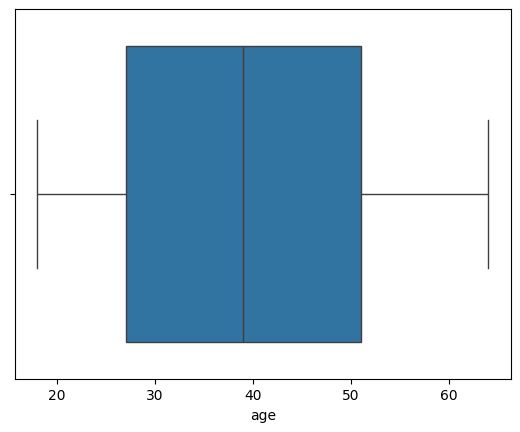

In [83]:
sns.boxplot(df,x='age')

<Axes: xlabel='bmi'>

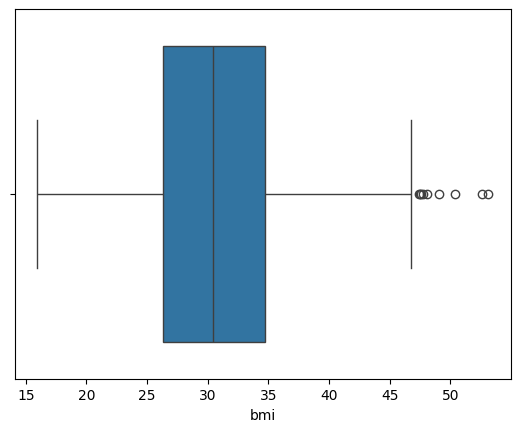

In [84]:
sns.boxplot(df,x='bmi')

<Axes: xlabel='charges'>

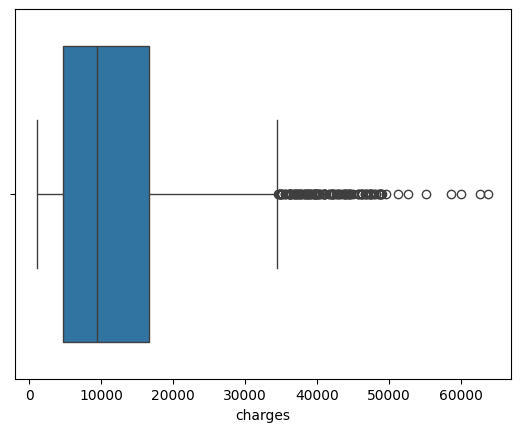

In [60]:
sns.boxplot(df,x='charges')

Outliers are in the `bmi` and `charges` column 

In [61]:
q1 = df['bmi'].quantile(0.25)
q3 = df['bmi'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR


In [62]:
df = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)] 

In [63]:
df.shape

(1328, 7)

<Axes: xlabel='bmi'>

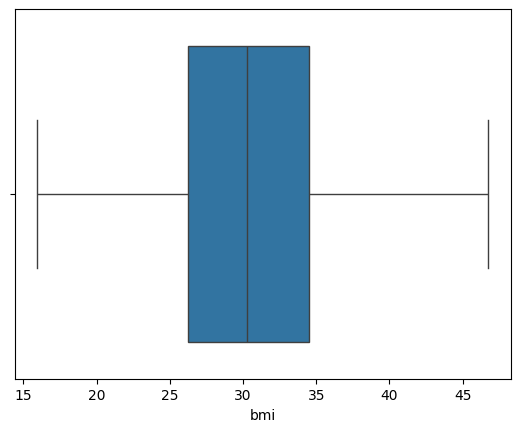

In [64]:
sns.boxplot(df,x='bmi')

In [65]:
q1 = df['charges'].quantile(0.25)
q3 = df['charges'].quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR


In [66]:
df = df[(df['charges'] >= lower_bound) & (df['charges'] <= upper_bound)] 

In [67]:
df.shape

(1190, 7)

<Axes: xlabel='charges'>

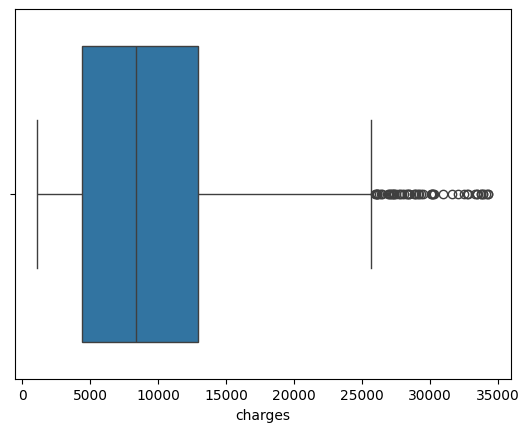

In [68]:
sns.boxplot(df,x='charges')

<Axes: xlabel='charges', ylabel='Count'>

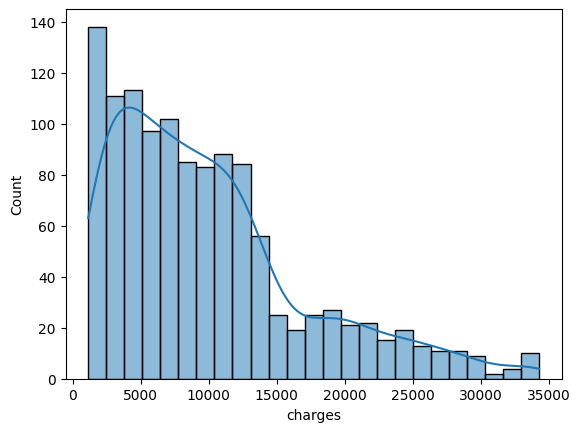

In [69]:
sns.histplot(df,x='charges', bins=25, kde=True)

after 25000 the outliers still present because the data is right skewed

In [70]:
import numpy as np
df['charges'] = np.log(df['charges'])  # it is used to compress the very high values

<Axes: xlabel='charges', ylabel='Count'>

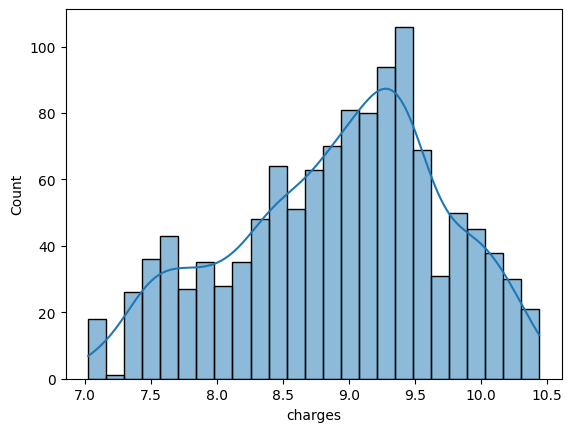

In [71]:
sns.histplot(df,x='charges', bins=25, kde=True)

Now the data looks normal

In [72]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,9.734176
1,18,male,33.770,1,no,southeast,7.453302
2,28,male,33.000,3,no,southeast,8.400538
3,33,male,22.705,0,no,northwest,9.998092
4,32,male,28.880,0,no,northwest,8.260197


In [73]:
df.sex.unique()

array(['female', 'male'], dtype=object)

In [74]:
df.smoker.unique()

array(['yes', 'no'], dtype=object)

In [75]:
df.region.unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [85]:
df['sex'] = df.sex.apply(lambda x: 1 if x == 'male' else 0)
df['smoker'] = df.smoker.apply(lambda x: 1 if x == 'yes' else 0)

In [86]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


sex and smoker columns are converted in to label encoded values

In [ ]:
df = pd.get_dummies(df, dtype=int) # provide dummy values as a seperate column

In [89]:
df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,0,1
1,18,1,33.770,1,0,1725.55230,0,0,1,0
2,28,1,33.000,3,0,4449.46200,0,0,1,0
3,33,1,22.705,0,0,21984.47061,0,1,0,0
4,32,1,28.880,0,0,3866.85520,0,1,0,0


In [ ]:
df.corr() # used to check the relation between variables/columns

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
age,1.000000,-0.019814,0.109344,0.041536,-0.025587,0.298308,0.001868,0.001495,-0.012311,0.009415
sex,-0.019814,1.000000,0.046397,0.017848,0.076596,0.058044,-0.002008,-0.012482,0.017578,-0.003767
bmi,0.109344,0.046397,1.000000,0.012755,0.003746,0.198401,-0.138178,-0.136138,0.270057,-0.006211
children,0.041536,0.017848,0.012755,1.000000,0.007331,0.067389,-0.023202,0.026044,-0.023492,0.021538
smoker,-0.025587,0.076596,0.003746,0.007331,1.000000,0.787234,0.002597,-0.036321,0.068282,-0.037168
charges,0.298308,0.058044,0.198401,0.067389,0.787234,1.000000,0.005945,-0.038695,0.073578,-0.043637
region_northeast,0.001868,-0.002008,-0.138178,-0.023202,0.002597,0.005945,1.000000,-0.319842,-0.345909,-0.320493
region_northwest,0.001495,-0.012482,-0.136138,0.026044,-0.036321,-0.038695,-0.319842,1.000000,-0.345909,-0.320493
region_southeast,-0.012311,0.017578,0.270057,-0.023492,0.068282,0.073578,-0.345909,-0.345909,1.000000,-0.346614
region_southwest,0.009415,-0.003767,-0.006211,0.021538,-0.037168,-0.043637,-0.320493,-0.320493,-0.346614,1.000000


In [90]:
X = df.drop('charges', axis=1)
y = df.charges

In [91]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

In [92]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [93]:
model.coef_

array([  248.21072022,  -101.54205399,   318.70144095,   533.0099888 ,
       23077.76459287,   472.45520552,    80.69375073,  -366.46441021,
        -186.68454604])

In [94]:
model.intercept_

np.float64(-11565.107501461818)

In [96]:
y_pred_train = model.predict(X_train)

In [97]:
from sklearn.metrics import mean_squared_error,r2_score

In [101]:
mean_squared_error(y_train,y_pred_train)

36979860.90472867

In [102]:
r2_score(y_train,y_pred_train)

0.7299057809339075

In [103]:
y_pred_test= model.predict(X_test)

In [104]:
mean_squared_error(y_test,y_pred_test)

35478020.6752356

In [105]:
r2_score(y_test,y_pred_test)

0.8069287081198012